# 📘 Support Vector Machine (SVM) – Complete Theory

## 1. Introduction
- **Support Vector Machine (SVM)** is a **supervised machine learning algorithm** used for **classification** and **regression**.
- The main idea: Find the **best boundary (hyperplane)** that separates different classes with the **maximum margin**.

---

## 2. Key Concepts
### 🔹 Hyperplane
- A decision boundary that separates classes.
- In 2D → line, in 3D → plane, in higher dimensions → hyperplane.

### 🔹 Support Vectors
- The closest data points to the hyperplane.
- They are critical because they define the margin.

### 🔹 Margin
- The distance between the hyperplane and the nearest support vectors.
- SVM maximizes this margin → more robust classification.

---

## 3. Types of SVM
| **Type** | **Description** | **Use Case** |
|----------|-----------------|--------------|
| **Linear SVM** | Separates data with a straight line | Spam vs. Non-spam emails |
| **Non-linear SVM (Kernel SVM)** | Uses kernel trick to separate complex data | Image recognition |
| **Support Vector Regression (SVR)** | Predicts continuous values | House price prediction |

---

## 4. Kernel Trick
### 🔹 What is Kernel Trick?
- A mathematical shortcut that allows SVM to **map data from lower dimension to higher dimension**.
- Makes non-linear data linearly separable in higher space.
- Instead of explicitly transforming data, kernels compute similarity in higher dimensions directly.

### 🔹 Why Needed?
- Some datasets cannot be separated by a straight line in their original dimension.
- Example: Points arranged in concentric circles → not separable in 2D, but separable if mapped to higher dimension.

### 🔹 Common Kernel Functions
1. **Linear Kernel**  
   - No transformation, simple dot product.  
   - Works when data is linearly separable.

2. **Polynomial Kernel**  
   - Maps data into polynomial features.  
   - Good for curved boundaries.

3. **RBF (Radial Basis Function) Kernel**  
   - Maps data into infinite dimensions.  
   - Powerful for complex, non-linear boundaries.

4. **Sigmoid Kernel**  
   - Similar to activation functions in neural networks.

---

## 5. Advantages of SVM
- High accuracy for classification tasks.
- Works well in high-dimensional spaces.
- Flexible with kernel trick.
- Robust to overfitting if margin is large.

---

## 6. Limitations of SVM
- Training can be slow on very large datasets.
- Harder to interpret compared to decision trees.
- Choosing the right kernel and parameters requires expertise.

---

## 7. Applications
- Text classification (spam detection, sentiment analysis).
- Image recognition (face detection).
- Bioinformatics (protein classification).
- Handwriting recognition.

---

## 8. Summary
- **SVM = Algorithm that finds the best boundary to separate classes.**
- **Support Vectors = Key points that define the margin.**
- **Kernel Trick = Implicitly converts lower-dimensional data into higher dimensions** to make separation possible.
- Best suited for **classification problems** with small to medium datasets.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("C:\\Users\\HP\\OneDrive\\Documents\\DataMites\\Machine learning\\indian_liver_patient.csv")

In [4]:
data.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [5]:
data.tail()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
578,60,Male,0.5,0.1,500,20,34,5.9,1.6,0.37,2
579,40,Male,0.6,0.1,98,35,31,6.0,3.2,1.10,1
580,52,Male,0.8,0.2,245,48,49,6.4,3.2,1.00,1
581,31,Male,1.3,0.5,184,29,32,6.8,3.4,1.00,1
582,38,Male,1.0,0.3,216,21,24,7.3,4.4,1.50,2


In [6]:
data.describe()

,Age,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
count,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,579.000000,583.000000
mean,44.746141,3.298799,1.486106,290.576329,80.713551,109.910806,6.483190,3.141852,0.947064,1.286449
std,16.189833,6.209522,2.808498,242.937989,182.620356,288.918529,1.085451,0.795519,0.319592,0.452490
min,4.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,1.000000
25%,33.000000,0.800000,0.200000,175.500000,23.000000,25.000000,5.800000,2.600000,0.700000,1.000000
50%,45.000000,1.000000,0.300000,208.000000,35.000000,42.000000,6.600000,3.100000,0.930000,1.000000
75%,58.000000,2.600000,1.300000,298.000000,60.500000,87.000000,7.200000,3.800000,1.100000,2.000000
max,90.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000,2.000000


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         583 non-null    int64  
 1   Gender                      583 non-null    object 
 2   Total_Bilirubin             583 non-null    float64
 3   Direct_Bilirubin            583 non-null    float64
 4   Alkaline_Phosphotase        583 non-null    int64  
 5   Alamine_Aminotransferase    583 non-null    int64  
 6   Aspartate_Aminotransferase  583 non-null    int64  
 7   Total_Protiens              583 non-null    float64
 8   Albumin                     583 non-null    float64
 9   Albumin_and_Globulin_Ratio  579 non-null    float64
 10  Dataset                     583 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 50.2+ KB


In [8]:
data.isna().sum()

Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Protiens                0
Albumin                       0
Albumin_and_Globulin_Ratio    4
Dataset                       0
dtype: int64

In [9]:
data.columns

Index(['Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin',
       'Alkaline_Phosphotase', 'Alamine_Aminotransferase',
       'Aspartate_Aminotransferase', 'Total_Protiens', 'Albumin',
       'Albumin_and_Globulin_Ratio', 'Dataset'],
      dtype='object')

In [10]:
data["Albumin_and_Globulin_Ratio"].fillna(data["Albumin_and_Globulin_Ratio"].median(), inplace=True)

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         583 non-null    int64  
 1   Gender                      583 non-null    object 
 2   Total_Bilirubin             583 non-null    float64
 3   Direct_Bilirubin            583 non-null    float64
 4   Alkaline_Phosphotase        583 non-null    int64  
 5   Alamine_Aminotransferase    583 non-null    int64  
 6   Aspartate_Aminotransferase  583 non-null    int64  
 7   Total_Protiens              583 non-null    float64
 8   Albumin                     583 non-null    float64
 9   Albumin_and_Globulin_Ratio  583 non-null    float64
 10  Dataset                     583 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 50.2+ KB


C:\Users\HP\AppData\Local\Temp\ipykernel_15692\996963029.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["Albumin_and_Globulin_Ratio"].fillna(data["Albumin_and_Globulin_Ratio"].median(), inplace=True)


In [16]:
# Encode categorical variable
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data["Gender"] = le.fit_transform(data.Gender)

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         583 non-null    int64  
 1   Gender                      583 non-null    int64  
 2   Total_Bilirubin             583 non-null    float64
 3   Direct_Bilirubin            583 non-null    float64
 4   Alkaline_Phosphotase        583 non-null    int64  
 5   Alamine_Aminotransferase    583 non-null    int64  
 6   Aspartate_Aminotransferase  583 non-null    int64  
 7   Total_Protiens              583 non-null    float64
 8   Albumin                     583 non-null    float64
 9   Albumin_and_Globulin_Ratio  583 non-null    float64
 10  Dataset                     583 non-null    int64  
dtypes: float64(5), int64(6)
memory usage: 50.2 KB


<Axes: xlabel='Total_Protiens', ylabel='count'>

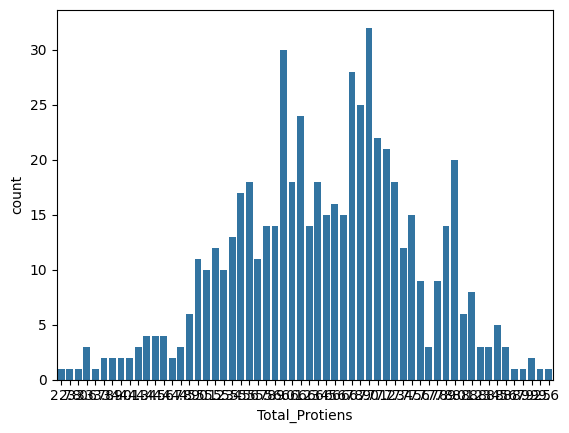

In [12]:
sns.countplot(x='Total_Protiens', data=data)

<Axes: xlabel='Gender', ylabel='count'>

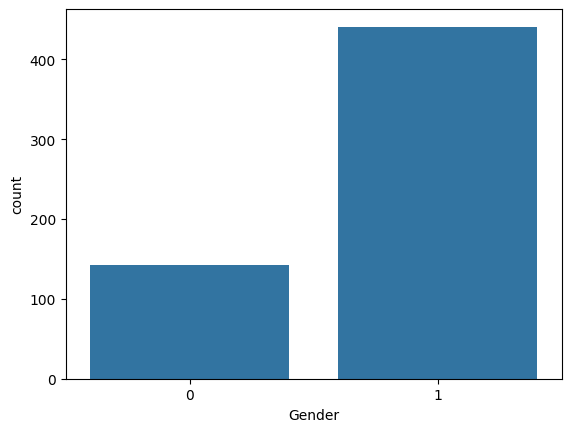

In [13]:
sns.countplot(x='Gender', data=data)

In [ ]:
sns.heatmap

In [14]:
# Create feature matrix (X) and target vector (y)
x = data[['Age', 'Total_Bilirubin', 'Direct_Bilirubin', 'Alkaline_Phosphotase', 
          'Alamine_Aminotransferase', 'Aspartate_Aminotransferase', 'Total_Protiens', 
          'Albumin', 'Albumin_and_Globulin_Ratio', 'Dataset']]

y = data['Gender']

In [15]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [17]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

In [18]:
x_train = sc.fit_transform(x_train)
x_test = sc.fit_transform(x_test)

In [19]:
from sklearn.svm import SVC
model = SVC()

In [24]:
# Model accuracy
print(f"SVM Accuracy: {model.score(x_test, y_test)}")

SVM Accuracy: 0.7948717948717948


In [22]:
y_predict = model.predict(x_test)

In [23]:
from sklearn.metrics import classification_report, confusion_matrix

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_predict))

# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_predict)
print(cm)

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        24
           1       0.79      1.00      0.89        93

    accuracy                           0.79       117
   macro avg       0.40      0.50      0.44       117
weighted avg       0.63      0.79      0.70       117


Confusion Matrix:
[[ 0 24]
 [ 0 93]]


C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

<Axes: >

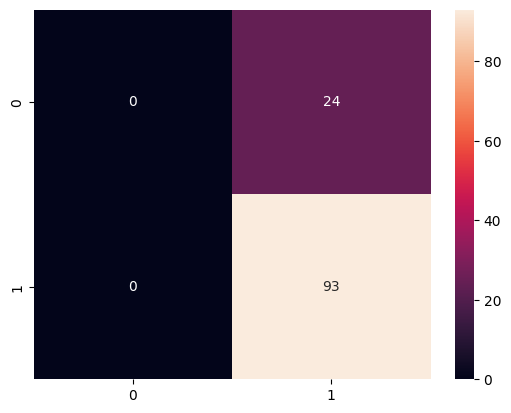

In [26]:
sns.heatmap(cm,annot=True)